# Why is the mould coming back?
## A diagnostic re-analysis of three months of bathroom sensor data

In February 2026, after losing a towel to mould and having the 
bathroom ceiling professionally cleaned, I built a sensor-based 
alert system. Three months later, I'm seeing the early signs of 
regrowth.

This notebook re-analyses the existing data to answer: 
**given that the original alert system was active, why did the 
underlying conditions for mould growth persist?**

The hypothesis: the original alert was using the wrong metric. 
Mould doesn't grow because air humidity is high — it grows because 
surface conditions reach near-saturation. These are related but 
not identical, and the difference matters.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [15]:

df = pd.read_csv("./data/bathroom.csv")
df['received_at'] = pd.to_datetime(df['received_at'])
df = df.set_index('received_at', drop=False)
df = df.sort_index()


## The original alert rule

The production alert service in [ops-check-service](https://github.com/jimyeong/ops-check-service) 
runs as a Node.js worker querying PostgreSQL on a fixed interval. 
The condition function evaluates a single rule, conceptually:

> "Within the last hour, if at least 90% of humidity readings are 
> above 60%, fire an alert."

The architecture passes this rule (and others) into a service layer 
via dependency injection — composable condition functions evaluated 
together. For this notebook's purpose, only the logic of this single 
rule matters; the production wiring is not reproduced here.

The pandas equivalent below evaluates the same rule against the 
historical data, generating the alert timeline that the production 
system would have produced.

In [19]:
# The Original rule
HIGH_HUMIDITY_THRESHOLD = 60   # %, matches production constant
HIGH_RATIO_THRESHOLD = 0.9     # 90%, matches production constant
RECENT_INTERVAL = '1h'         # rolling window
MIN_READINGS = 10              # minimum readings for valid evaluation

df['high_humidity'] = df['humidity'] >= HIGH_HUMIDITY_THRESHOLD

# Rolling: fraction of last 1h readings that exceeded threshold
df['high_ratio'] = df['high_humidity'].rolling(RECENT_INTERVAL).mean()
df['readings_in_window'] = df['high_humidity'].rolling(RECENT_INTERVAL).count()

# Alert fires when both conditions hold
df['original_alert'] = (
    (df['readings_in_window'] >= MIN_READINGS) & 
    (df['high_ratio'] >= HIGH_RATIO_THRESHOLD)
)

print(f"Original rule fired alerts: {df['original_alert'].sum()} times over {len(df)} readings")
print(f"Active alert ratio: {df['original_alert'].mean() * 100:.1f}% of time")

Original rule fired alerts: 2128 times over 18255 readings
Active alert ratio: 11.7% of time


## Physics correction


The original rule treated humidity as the predictive metric. The problem: humidity alone doesn't tell you whether **surfaces** are at risk. Mould doesn't germinate because the air is humid — it germinates because surface conditions reach near-saturation.

These are related, but not the same. Here's why the distinction matters.


### The concept of dew point

Air has a finite capacity to hold water vapour, and that capacity depends on temperature. Warmer air can hold more; cooler air less. When air cools enough that its vapour content reaches its maximum capacity, the excess condenses into liquid water. That threshold temperature is the **dew point**.

A useful way to think about it: imagine each cubic metre of air as a container whose size depends on temperature. The amount of water inside is fixed (until something adds or removes moisture). As the container shrinks (temperature drops), the water inside takes up a larger fraction of the available space. Once it fills 
100%, anything extra has to come out — that's condensation.

### Why this matters for mould

Cold surfaces in a warm humid room (bathroom wall, ceiling, window edges) cool the air immediately next to them. Even if the room's air humidity is 70%, the air *touching* a cold surface may already be at 100% — and that surface is where condensation forms, and where mould grows.

The **dew-point spread** — the gap between current air temperature and dew point — captures how close conditions are to that saturation point. A small spread means surfaces only slightly 
colder than the air will already be at risk.


### The threshold I chose

Strictly, condensation begins when spread reaches 0°C. But mould risk doesn't wait for condensation — sustained near-saturation on a surface is enough. To approach this conservatively, I treat spread ≤ 3°C as the warning zone:

```python
df['spread'] = df['temperature'] - df['dew_point']
df['is_risk'] = df['spread'] <= 3   # conservative warning threshold
```
This is a deliberately precautionary choice rather than a physical threshold. The actual surface conditions depend on the specific surface temperature, which a room-air sensor doesn't directly measure — the 3°C buffer accounts for that uncertainty.

### Calculating dew point

The Magnus-Tetens approximation is the standard formula for dew 
point from temperature and relative humidity:
```python
def calculate_dew_point(temp_c, rh_pct):
   
    A, B = 17.625, 243.04
    alpha = np.log(rh_pct / 100) + (A * temp_c) / (B + temp_c)
    return (B * alpha) / (A - alpha)

df['dew_point'] = calculate_dew_point(df['temperature'], df['humidity'])
df['spread']    = df['temperature'] - df['dew_point']
```

### Re-analysing the same data with the new metric

When I re-evaluated the past month of sensor data using dew-point spread instead of relative humidity, the picture changed. The warning threshold (spread ≤ 3°C) was crossed **121 times**, with **51 events sustained beyond 30 minutes** — a far higher burden than the original humidity-based rule had captured.
Below: the dew-point spread over the past month. The green line dips toward the warning threshold (3°C) far more often than relative humidity exceeded 60%.

In [ ]:
n_events = len(durations)
n_long_events = (durations > 30).sum()
print(f"Total mould-risk events: {n_events}")
print(f"Events sustained > 30 min: {n_long_events}")

Total mould-risk events: 121
Events sustained > 30 min: 51


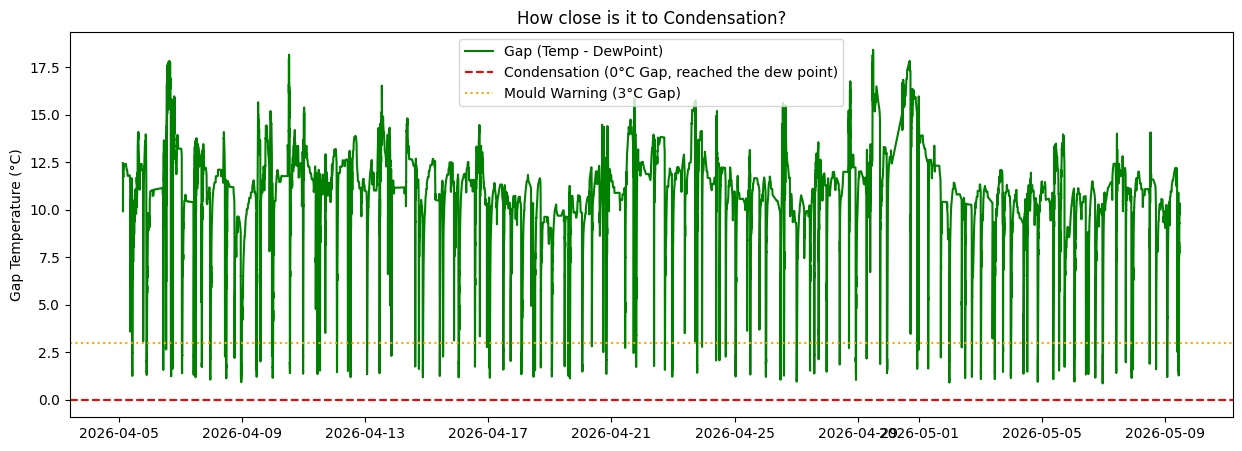

In [26]:


plt.figure(figsize=(15, 5))
plt.plot(df.index, df['spread'], color='green', label='Gap (Temp - DewPoint)')
plt.axhline(y=0, color="red", linestyle="--", label="Condensation (0°C Gap, reached the dew point)")
plt.axhline(y=3, color="orange", linestyle=":", label="Mould Warning (3°C Gap)")
plt.fill_between(df.index, df['spread'], 0, where=(df['spread'] <= 0), color='red', alpha=0.5)
plt.title("How close is it to Condensation?")
plt.ylabel("Gap Temperature (°C)")
plt.legend()
plt.show()

Based on this re-analysis, the dew-point spread crosses below 3°C far more frequently than I had assumed. I had thought I was managing mould well with the dehumidifier and passive ventilation. The chart says otherwise — and three months later, the ceiling confirms it.

![Ceiling Now](./images/ceiling_after.jpeg)

*Three months after professional cleaning. The yellow staining and scattered brown specks are the early colonies forming on the same ceiling — the visible result of months of sustained exposure events captured in the data above*

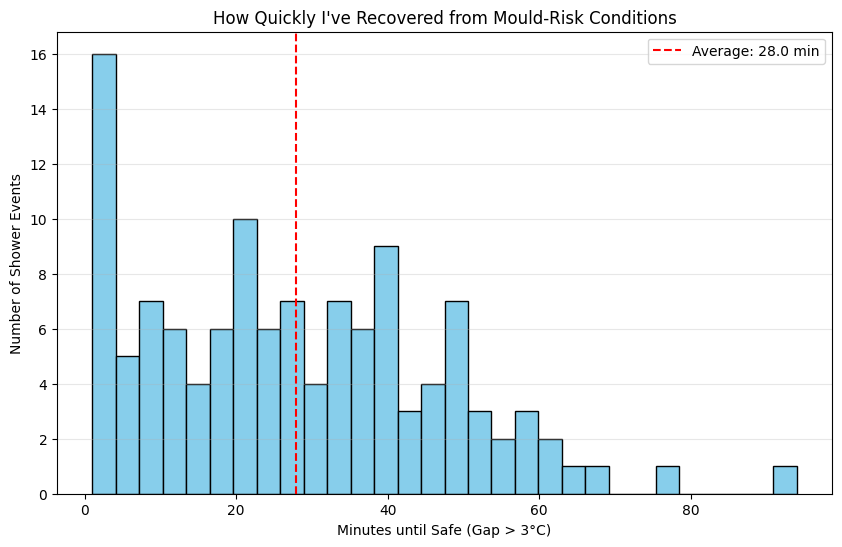

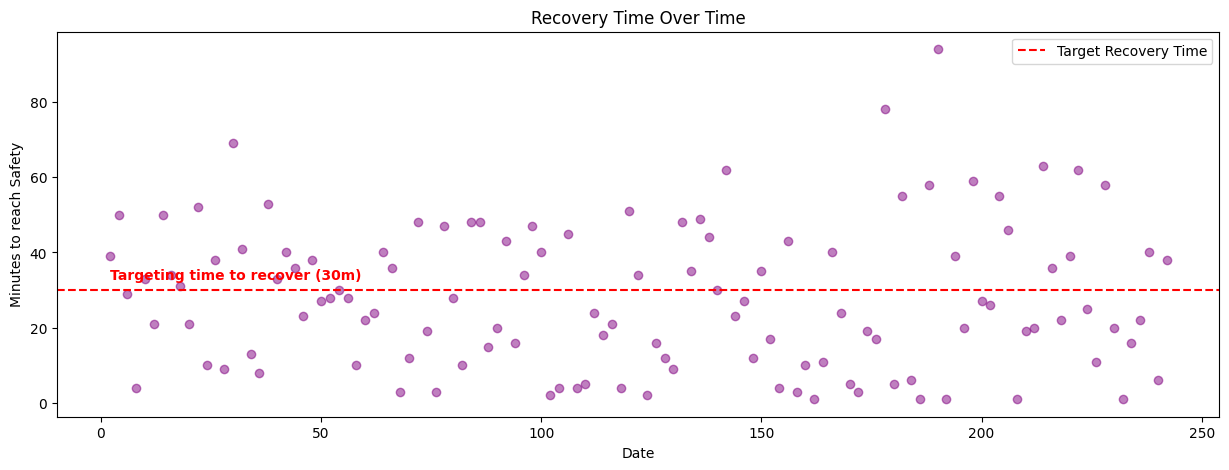

In [27]:

df['is_risk'] = (df['temperature'] - df['dew_point'] < 3)
df['group'] = (df['is_risk'] != df['is_risk'].shift()).cumsum()
durations = df[df['is_risk']].groupby('group').size()
plt.figure(figsize=(10, 6))
plt.hist(durations, bins=30, color='skyblue', edgecolor='black')
plt.axvline(durations.mean(), color='red', linestyle='--', label=f'Average: {durations.mean():.1f} min')


plt.title("How Quickly I've Recovered from Mould-Risk Conditions")
plt.xlabel('Minutes until Safe (Gap > 3°C)')
plt.ylabel('Number of Shower Events')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(15, 5))
risk_ends = df[df['is_risk']].groupby('group').last()
plt.scatter(risk_ends.index, durations, color='purple', alpha=0.5)
plt.xlabel('Date')

plt.axhline(y=30, color='red', linestyle='--', linewidth=1.5, label='Target Recovery Time')

plt.text(risk_ends.index[0], 32, 'Targeting time to recover (30m)', 
         color='red', fontweight='bold', va='bottom')

plt.title('Recovery Time Over Time')
plt.ylabel('Minutes to reach Safety')
plt.xlabel('Date')
plt.legend() 
plt.show()



The recovery distribution is heavily skewed toward short events (under 10 minutes), but a substantial tail extends beyond 30, 50, even 80 minutes. The average — 28 minutes — masks this bimodality. The long-tail events are where mould-favourable conditions persist; these are the ones that matter.

## Next phase — expanding sensor coverage

The analysis above ran on what was available: bathroom air T/RH. 
The limitations are visible — recovery dynamics vary, but the 
data can't tell me **why**. Was the window open? Did the 
dehumidifier run? How long was the shower?

To resolve this, the next iteration adds:

- **Window contact sensor** (Sonoff SNZB-04P) — captures 
  open/closed state
- **Smart plug on dehumidifier** (Sonoff S31 Lite ZB) — runtime 
  and power consumption
- **Smart plug on circulation fan** (Honeywell HT900E) — active 
  air movement as a controlled variable

<div style="display: flex; gap: 10px;">
  <img src="./images/bathroom_fan.jpeg" alt="Bathroom Fan" style="width: 50%;">
  <img src="./images/window_sensor.jpeg" alt="Window Sensor" style="width: 50%;">
</div>

The next notebook in this series will analyse recovery dynamics across these intervention modes — answering which combination actually moves recovery time, and by how much.